# Problem Statement

* Customer churn is a major challenge for telecom companies, as losing customers directly impacts long-term revenue.  
* The goal of this project is to analyze customer behavior patterns and build a machine learning model that predicts the likelihood of a customer leaving the service.

# Business Objective

* The objective is to identify customers who are likely to churn so that the company can implement targeted retention strategies.  
* By predicting churn risk early, businesses can improve customer satisfaction, reduce attrition, and optimize marketing efforts.

# Success Metric

* The primary evaluation metric for this project is **ROC-AUC**, as it measures the model’s ability to distinguish churn and non-churn customers across classification thresholds.  
* Additional metrics such as **Recall, Precision, and F1-score** are also considered to ensure balanced predictive performance.

## Folder Setup and Dataset Organization

This approach keeps raw data organized and allows the notebook to use consistent relative file paths.

In [34]:
!mkdir -p data
!mv WA_Fn-UseC_-Telco-Customer-Churn.csv data/WA_Fn-UseC_-Telco-Customer-Churn.csv

# Import Libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_PATH = 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "Dataset not found. Please upload data/WA_Fn-UseC_-Telco-Customer-Churn.csv into the data/ folder."
    )

df = pd.read_csv(DATA_PATH)

# Data Loading

In [36]:
dataset = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df = dataset.copy()

df.columns = df.columns.str.replace(r'([a-z])([A-Z])', r'\1_\2', regex=True).str.lower()

df.shape


(7043, 21)


* The Telco Customer Churn dataset was loaded and a copy was created to preserve the original data.  
* Column names were standardized to a consistent snake_case format to improve readability and maintain uniform feature naming throughout the analysis pipeline.

# Initial Data Inspection

In [37]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



* The dataset contains **7,043 customer records and 21 features**, including demographic, service usage, and billing information.  
* Initial inspection shows a mix of categorical and numerical variables, with `TotalCharges` incorrectly stored as an object type, indicating the need for data type correction during cleaning.

## Initial Data Quality Assessment

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   gender             7043 non-null   object 
 2   senior_citizen     7043 non-null   int64  
 3   partner            7043 non-null   object 
 4   dependents         7043 non-null   object 
 5   tenure             7043 non-null   int64  
 6   phone_service      7043 non-null   object 
 7   multiple_lines     7043 non-null   object 
 8   internet_service   7043 non-null   object 
 9   online_security    7043 non-null   object 
 10  online_backup      7043 non-null   object 
 11  device_protection  7043 non-null   object 
 12  tech_support       7043 non-null   object 
 13  streaming_tv       7043 non-null   object 
 14  streaming_movies   7043 non-null   object 
 15  contract           7043 non-null   object 
 16  paperless_billing  7043 

In [39]:
df.dtypes.value_counts()

,count
object,18
int64,2
float64,1



* The dataset is dominated by **categorical service-related attributes**, which represent customer subscription choices and service usage patterns.  


## Categorical Feature Exploration


In [40]:
for i in df.select_dtypes(include=['object']).columns:
    print(f"{i}: {df[i].unique()}")
    print('----'*31,'\n\n')

customer_id: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
---------------------------------------------------------------------------------------------------------------------------- 


gender: ['Female' 'Male']
---------------------------------------------------------------------------------------------------------------------------- 


partner: ['Yes' 'No']
---------------------------------------------------------------------------------------------------------------------------- 


dependents: ['No' 'Yes']
---------------------------------------------------------------------------------------------------------------------------- 


phone_service: ['No' 'Yes']
---------------------------------------------------------------------------------------------------------------------------- 


multiple_lines: ['No phone service' 'No' 'Yes']
-----------------------------------------------------------------------------------------------------------------


* Unique value inspection helps identify possible data inconsistencies, redundant categories, or encoded missing values such as "No internet service" or "No phone service".  
*These values provide insight into service availability and customer subscription behavior, which may influence churn patterns.

In [41]:
df.isnull().sum()

,0
customer_id,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0
online_security,0


In [42]:
df.duplicated().sum()

np.int64(0)

### Initial Observations

- `TotalCharges` is stored as an object and requires conversion to numeric.  
- No duplicate records were detected.  
- The dataset contains both numerical customer metrics and categorical service attributes, requiring different preprocessing strategies.

# Data Cleaning

In [43]:
df.drop(columns='customer_id',inplace=True)



* The `customer_id` column was removed as it is a unique identifier and does not provide predictive information for churn modeling.  
* Including such identifiers can introduce noise and negatively affect model generalization.

## Data Transformation

### Target Variable Encoding


In [44]:
df["churn"] = df["churn"].map({"Yes":1, "No":0})


* The churn variable was converted from categorical values ("Yes"/"No") into binary format (1/0), This transformation allows machine learning algorithms to interpret churn as a numerical classification target.

### Correcting Data Types


In [45]:
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

### Data Quality Observation

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             7043 non-null   object 
 1   senior_citizen     7043 non-null   int64  
 2   partner            7043 non-null   object 
 3   dependents         7043 non-null   object 
 4   tenure             7043 non-null   int64  
 5   phone_service      7043 non-null   object 
 6   multiple_lines     7043 non-null   object 
 7   internet_service   7043 non-null   object 
 8   online_security    7043 non-null   object 
 9   online_backup      7043 non-null   object 
 10  device_protection  7043 non-null   object 
 11  tech_support       7043 non-null   object 
 12  streaming_tv       7043 non-null   object 
 13  streaming_movies   7043 non-null   object 
 14  contract           7043 non-null   object 
 15  paperless_billing  7043 non-null   object 
 16  payment_method     7043 

In [47]:
df.isnull().sum()


,0
gender,0
senior_citizen,0
partner,0
dependents,0
tenure,0
phone_service,0
multiple_lines,0
internet_service,0
online_security,0
online_backup,0




* The `total_charges` feature was converted from object to numeric format.  
During conversion, some rows contained empty string values which were interpreted as missing values, revealing **11 null entries** in the dataset.
* After numeric conversion, values are correctly identified as missing, highlighting the importance of validating data types during preprocessing.

## Missing Value Handling


In [48]:
df.dropna(inplace=True)


* Since only **11 rows (<0.2% of the dataset)** were affected, their removal does not significantly impact the dataset distribution or model performance.

In [49]:
df.isnull().sum().sum()

np.int64(0)

In [50]:
df.dtypes.value_counts()


,count
object,15
int64,3
float64,2


## Numerical Feature Overview


In [51]:
df.describe()

,senior_citizen,tenure,monthly_charges,total_charges,churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000



* Descriptive statistics reveal that customer tenure ranges from **1 to 72 months**, with an average monthly charge of approximately **$64.8**.  
* The churn rate in the dataset is about **26.5%**, indicating a moderately imbalanced classification problem.

# Exploratory Data Analysis

## Univariate Analysis

### Target Value Analysis

In [52]:
df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,73.421502
1,26.578498


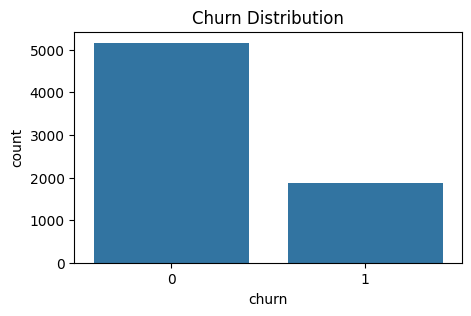

In [53]:
plt.figure(figsize=(5,3))

sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()

### Target Value Insights

* The dataset is moderately imbalanced.
* Approximately ~27% of customers churn.
* Accuracy alone may be misleading.
* Metrics like Recall and ROC-AUC will be important.

### Numerical Features

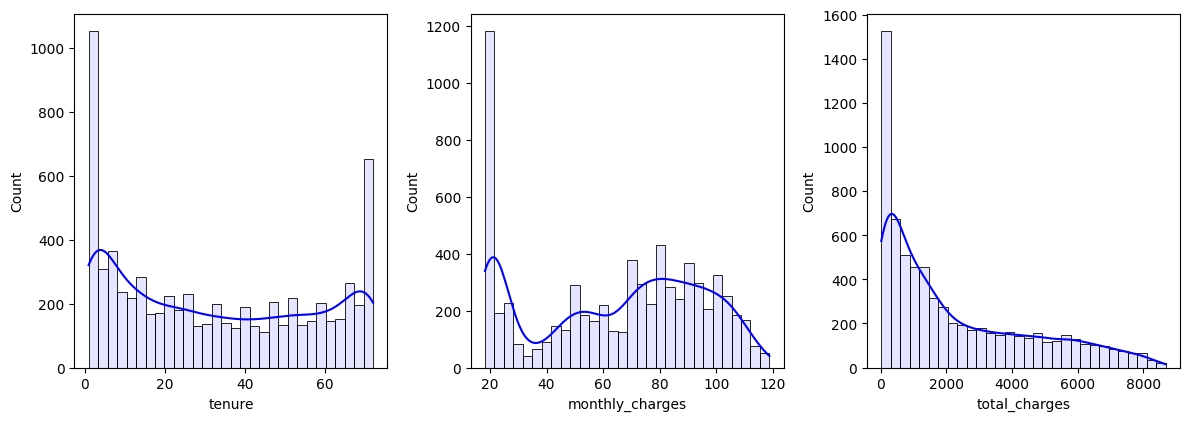

In [54]:
num_cols = ["tenure", "monthly_charges", "total_charges"]
df_num = df[num_cols]

plt.figure(figsize=(12,8))

for idx, col in enumerate(df_num, 1):
    plt.subplot(2, 3, idx)
    sns.histplot(df[col], bins=30, kde=True,color='blue', alpha=0.1)
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Univariate Analysis Insights (Numerical Feature):

**Tenure**

* The tenure distribution shows a large concentration of customers with shorter service duration.  
* This indicates many customers are relatively new to the service, while a smaller group remains subscribed for long periods.

**MonthlyCharges**

- Monthly charges range roughly from 20 to 120.
- The distribution appears slightly right-skewed.
- Many customers fall within the mid-to-high pricing range.

**TotalCharges**
* Total charges show strong right skewness because it represents accumulated billing over time.  
* Customers with longer tenure naturally have higher total spending.

## Outlier Detection

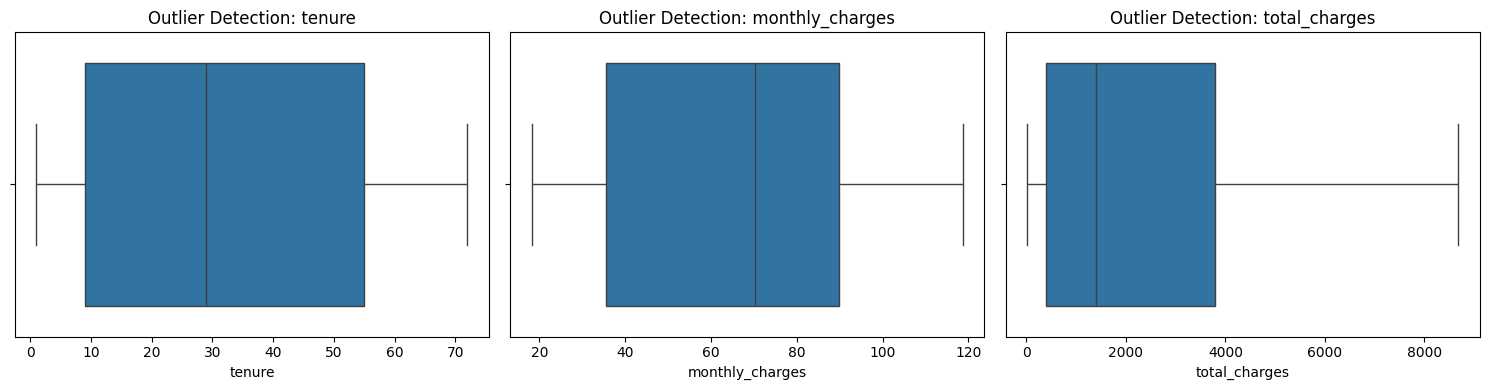

In [55]:

plt.figure(figsize=(15,4))

for i, col in enumerate(df_num):
    plt.subplot(1,3,i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection: {col}")

plt.tight_layout()
plt.show()

### Outlier Detection Insights

* Boxplots indicate that the numerical variables do not contain significant extreme outliers.  
* The observed ranges appear consistent with realistic customer billing and tenure values, so no outlier treatment is required.

### Univariate Analysis Summary

The numerical features exhibit varying distribution patterns. Tenure shows a high concentration of new customers, while TotalCharges demonstrates strong right skewness due to its cumulative nature. MonthlyCharges are moderately distributed across different pricing tiers. These distributions suggest that tenure and billing-related variables may play an important role in customer churn behavior.

## Bivariate Analysis

### Categorical Features

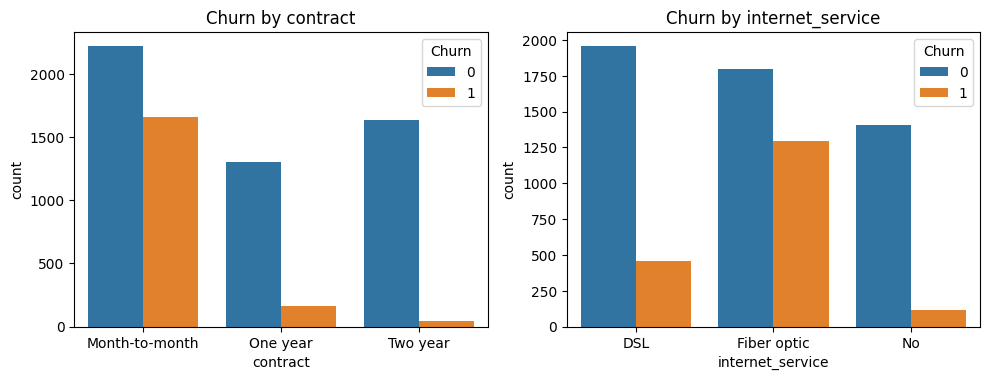

In [56]:
cat_cols = ["contract", "internet_service"]
df_catg = df[cat_cols]

plt.figure(figsize=(10,7))

for idx, col in enumerate(cat_cols):
    plt.subplot(2, 2, idx+1)
    sns.countplot(x=col, hue="churn", data=df)
    plt.title(f"Churn by {col}")
    plt.legend(title="Churn")

plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()


### Categorical Features insights:

 * **Contract Type**- Customers with month-to-month contracts exhibit significantly higher churn rates and on long-term contracts is much lower churn, Suggests contract commitment plays a strong role in retention.

*  **Internet Service Type** - Customers using Fiber Optic internet demonstrate higher churn compared to DSL users and without internet service have the lowest churn. This may indicate pricing sensitivity or service quality issues among fiber users.

* **Tech Support** - Customers without tech support churn at a much higher rate.
Subscribing to tech support appears to increase customer retention.

* **Online Security**- Customers without online security services show higher churn probability, Additional security features may contribute to perceived service value.



### Churn Percentage by Category

In [57]:
pd.crosstab(df["contract"], df["churn"], normalize="index") * 100

churn,0,1
contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [58]:
pd.crosstab(df["internet_service"], df["churn"], normalize="index") * 100


churn,0,1
internet_service,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


## Multivariate Analysis

### Multivariate Feature Relationships

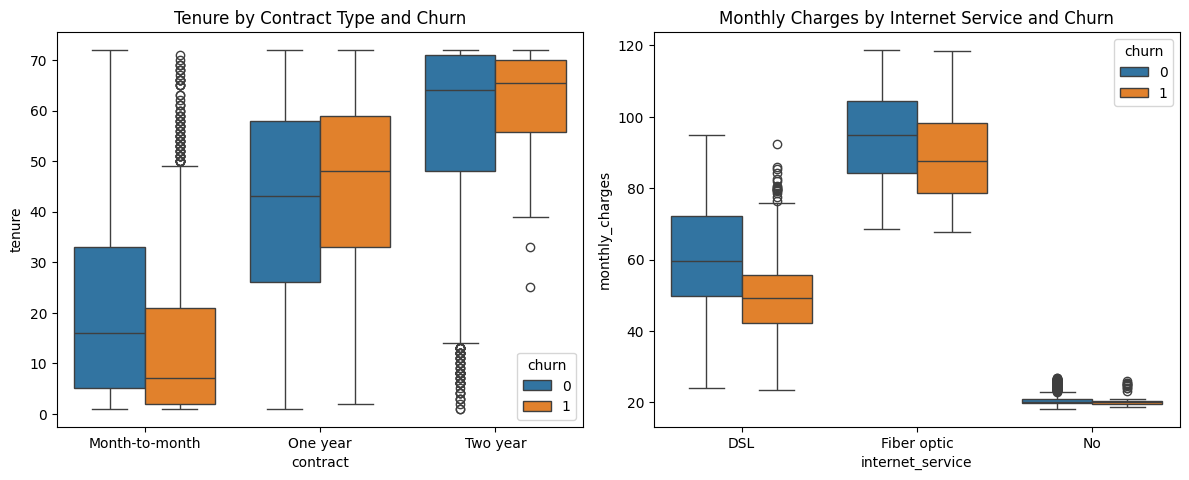

In [59]:
plt.figure(figsize=(12,9))

plt.subplot(2,2,1)
sns.boxplot(x="contract", y="tenure", hue="churn", data=df)
plt.title("Tenure by Contract Type and Churn")

plt.subplot(2,2,2)
sns.boxplot(x="internet_service", y="monthly_charges", hue="churn", data=df)
plt.title("Monthly Charges by Internet Service and Churn")

plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()

## Multivariate Feature Analysis Insights:

**Tech Support & Online Security vs Churn**
- Customers lacking both tech support and online security show highest churn.
- Customers subscribing to both services have significantly lower churn.
- Service bundling strategies could reduce customer attrition.

**Monthly Charges & Internet Service vs Churn**
- Fiber Optic customers pay higher charges and churn more.
- High monthly charges correlate with increased churn.
- Price sensitivity appears stronger in premium service users.



## Correlation Analysis of Numerical Features

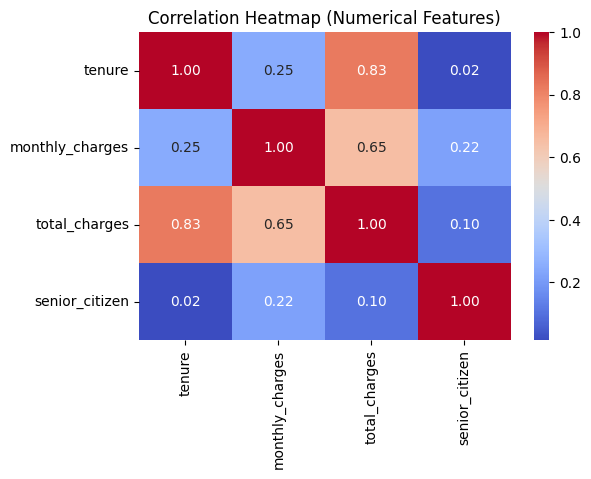

In [60]:
plt.figure(figsize=(6,4))

corr = df[["tenure", "monthly_charges", "total_charges", "senior_citizen"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

## Correlation Heatmap Analysis

- Tenure and TotalCharges show strong positive correlation.
  This is expected since total charges accumulate over time.
  
- MonthlyCharges has moderate correlation with TotalCharges.

- SeniorCitizen shows very weak correlation with other numerical features.

This indicates that tenure is an important driver of total billing amount.



## Overall EDA Conclusion

Exploratory analysis reveals several key patterns influencing customer churn.  
Customers with month-to-month contracts, fiber optic internet services, and higher monthly charges exhibit higher churn rates. Additionally, lack of services such as technical support and online security significantly increases churn probability.

Tenure plays a critical role in retention, as long-term customers are much less likely to churn. These findings suggest that service quality, pricing structure, and customer engagement services are important drivers of customer retention and should be considered in churn prevention strategies.

## Business Implications

* The analysis suggests that improving service support, offering bundled services, and encouraging longer-term contracts could significantly reduce churn.  
* Targeting high-risk groups such as fiber optic users and customers on month-to-month contracts may help telecom companies implement more effective retention strategies.

# Data Preprocessing

## Import Preprocessing Libraries

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

## Train–Test Split

In [62]:
X = df.drop("churn", axis=1)
y = df["churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Feature Seperation

In [63]:
num_cols = X_train.select_dtypes(exclude='object').columns

cat_cols = X_train.select_dtypes(include='object').columns


print("num_cols are ", num_cols,'\n\n', 'cat_cols are ', cat_cols)


num_cols are  Index(['senior_citizen', 'tenure', 'monthly_charges', 'total_charges'], dtype='object') 

 cat_cols are  Index(['gender', 'partner', 'dependents', 'phone_service', 'multiple_lines',
       'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method'],
      dtype='object')


## Column Tranformation

In [64]:
preprocessor = ColumnTransformer(
                transformers = [

                ('num', StandardScaler(), num_cols),
                ('catog.', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)

                ]
                                  )


* A ColumnTransformer is used to apply **StandardScaler** to numerical variables and **OneHotEncoder** to categorical variables.  
* This ensures that all features are transformed appropriately within a single preprocessing pipeline, preventing data leakage and maintaining consistency during model training and inference.

# Machine Learning Model Pipeline


## Import Models


In [65]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [66]:
pipe_lr = Pipeline( [
            ('preprocessor', preprocessor),
              ('model',LogisticRegression( max_iter=1000, class_weight='balanced', solver='liblinear',C=1.0 ))
         ] )

pipe_Knn = Pipeline( [
            ('preprocessor', preprocessor),
              ('model',KNeighborsClassifier( n_neighbors=5, weights='distance',metric='minkowski'))
         ] )

pipe_svc = Pipeline( [
            ('preprocessor', preprocessor),
              ('model',SVC( probability=True, class_weight='balanced',C=1.0 , gamma='scale'))
         ] )

pipe_Dt = Pipeline( [
            ('preprocessor', preprocessor),
              ('model',DecisionTreeClassifier( random_state=42, min_samples_split=5, class_weight='balanced'))
         ] )

pipe_Rf = Pipeline( [
            ('preprocessor', preprocessor),
              ('model',RandomForestClassifier( random_state=42, min_samples_split=5, class_weight='balanced'))
         ] )

pipe_xgb = Pipeline( [
            ('preprocessor', preprocessor),
              ('model',XGBClassifier( eval_metric='logloss', random_state=42))
         ] )


# Models Stored Together
models = {
    'Logistic Regression': pipe_lr,
    'KNeighborsClassifier': pipe_Knn,
    'SVC': pipe_svc,
    'DecisionTreeClassifier': pipe_Dt,
    'RandomForestClassifier': pipe_Rf,
    'XGBClassifier': pipe_xgb

}



* Each model is integrated into a Scikit-learn Pipeline combining preprocessing and classification.  
* This approach ensures that data transformations and model training occur sequentially within a single workflow, enabling fair comparison across multiple algorithms while preventing preprocessing inconsistencies.

## Baseline Models Performance Analysis

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


results = []

for name, model in models.items():

    # train model
    model.fit(X_train, y_train)

    # predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)



    print("Model:", name)
    print("Accuracy:", acc, "| Precision:", precision, "| Recall:", recall, "| F1 Score:", f1)
    print("ROC AUC:", roc)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print("\n---------------------------\n")

    results.append([name, acc, precision, recall, f1, roc])





Model: Logistic Regression
Accuracy: 0.7249466950959488 | Precision: 0.48929159802306427 | Recall: 0.7941176470588235 | F1 Score: 0.6055045871559633
ROC AUC: 0.8354191364128156

Confusion Matrix
[[723 310]
 [ 77 297]]

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.72      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.72      0.74      1407


---------------------------

Model: KNeighborsClassifier
Accuracy: 0.7533759772565742 | Precision: 0.5365853658536586 | Recall: 0.5294117647058824 | F1 Score: 0.5329744279946165
ROC AUC: 0.769903349881711

Confusion Matrix
[[862 171]
 [176 198]]

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1033
           1       0.54      0.53      0.53       374


* Each pipeline was trained and evaluated on the test dataset using multiple metrics including accuracy, precision, recall, F1-score, and ROC-AUC.  
* This baseline evaluation provides an initial understanding of how different algorithms perform on the churn prediction task before applying hyperparameter optimization.

### Baseline Model Performance Comparison


In [68]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
])

results_df.sort_values(by="ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.724947,0.489292,0.794118,0.605505,0.835419
4,RandomForestClassifier,0.782516,0.589947,0.596257,0.593085,0.822247
5,XGBClassifier,0.778252,0.589080,0.548128,0.567867,0.819670
2,SVC,0.721393,0.485000,0.778075,0.597536,0.813332
1,KNeighborsClassifier,0.753376,0.536585,0.529412,0.532974,0.769903
3,DecisionTreeClassifier,0.713575,0.466513,0.540107,0.500620,0.667594


### Baseline Model Performance Comparison Interpretation

* The evaluation results were compiled into a comparison table to identify which algorithms perform best on the churn prediction task.  
* Logistic Regression achieved the highest ROC-AUC among baseline models, indicating strong ability to distinguish churn and non-churn customers even before hyperparameter tuning.

## Baseline Model Performance Visualization


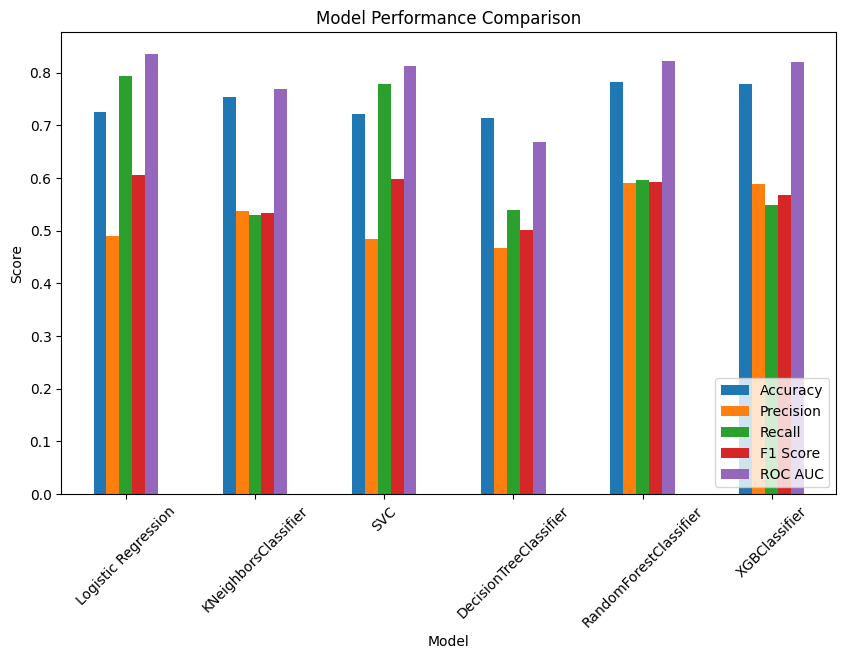

In [69]:
results_df.set_index("Model").plot( kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()


* A bar plot was used to visually compare model performance across evaluation metrics.  
* Visualization helps quickly identify strengths and weaknesses of each algorithm and highlights models that warrant further optimization.

## ROC Curve Comparison


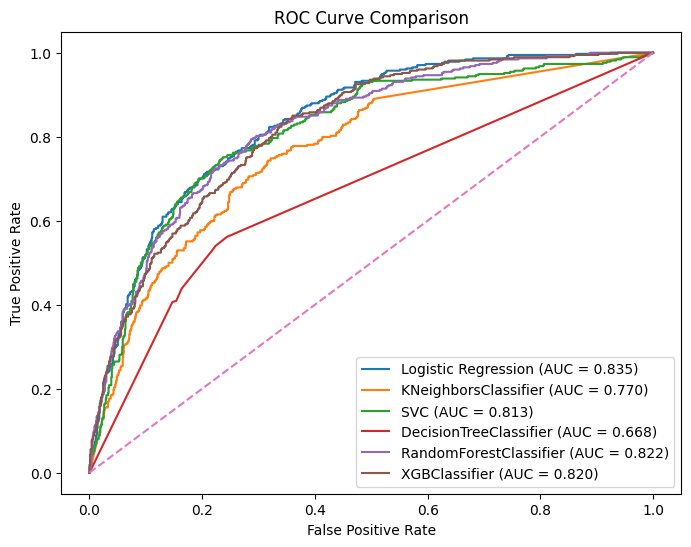

In [70]:

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():

    # probability predictions
    y_prob = model.predict_proba(X_test)[:,1]

    # calculate curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # calculate auc
    roc_auc = auc(fpr, tpr)

    # plot
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# random classifier line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### ROC Curve Comparison Intepretation


* The ROC curves illustrate the classification performance of each baseline model across different decision thresholds.  
* Logistic Regression demonstrates the highest ROC-AUC among the baseline models, indicating a stronger ability to distinguish between churn and non-churn customers.

* Random Forest and XGBoost also show competitive performance, while Decision Tree and KNN exhibit comparatively lower discrimination capability.  
* Overall, Logistic Regression, Random Forest, and XGBoost appear to be the most promising candidates for further hyperparameter optimization.

# Model Selection

### Selected Models for Further Optimization

* Based on baseline ROC-AUC performance, **Logistic Regression, Random Forest, and XGBoost** are selected for further hyperparameter tuning.  
* These models demonstrated the strongest ability to capture churn patterns and were therefore optimized to achieve improved predictive performance.

## Logistic Regression Model

### Logistic Regression Hyperparameter Optimization


In [71]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# hyperparameter space
parame_lr = {

    'model__penalty': ['l1', 'l2'],
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'saga'],

}

# cross validation strategy
Cv = StratifiedKFold( n_splits= 5, shuffle = True, random_state = 42)

# RandomizedSearchCV
log_reg_search = RandomizedSearchCV( pipe_lr, param_distributions= parame_lr, n_iter = 20, scoring = 'roc_auc', cv = Cv, n_jobs= -1 )

# fit
log_reg_search.fit(X_train,y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['senior_citizen', 'tenure', 'monthly_charges', 'total_charges'], dtype='object')),
                                                                              ('catog.',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               Index(['gender', 'partner',...
       'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies',
       'contract', 'paperless_billing', 'payment_method'],
      dtype='object'))])),
                                             ('model',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=1000,
                                                                 solver='liblinear'))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__C': [0.001, 0.01, 0.1, 1, 10,
                                                     100],
                                        'model__penalty': ['l1', 'l2'],
                                        'model__solver': ['liblinear', 'saga']},
                   scoring='roc_auc')

* Logistic Regression learns model parameters by minimizing the **log-loss (cross-entropy) cost function**, which measures how well predicted probabilities match actual outcomes.  
* RandomizedSearchCV with Stratified K-Fold cross-validation is used to tune regularization strength and solver choice, ensuring the model generalizes well while preventing overfitting through optimal regularization.

### Logistic Regression Optimized Model Configuration


In [72]:
print('Best_Parameters: ',log_reg_search.best_params_)
print('Best_roc_auc_score: ',log_reg_search.best_score_)


Best_Parameters:  {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 100}
Best_roc_auc_score:  0.8461862382275058



* The tuning process selected **L2 regularization with C=100 using the liblinear solver**, indicating that a relatively weaker regularization provided the best performance on the dataset.  
* The cross-validated ROC-AUC score of **0.846** suggests the model has strong ability to distinguish between churn and non-churn customers across different probability thresholds.

### Logistic Regression Test Set analysis


In [73]:

best_lr = log_reg_search.best_estimator_

y_pred = best_lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy}")
print('\n')
print('Confusion_matrix : \n\n',confusion_matrix(y_test, y_pred))
print('\n')
print('Classification report: \n\n',classification_report(y_test, y_pred))
print('\n')
print('lr model trained data score',best_lr.score(X_train, y_train))
print('lr model tested data score',best_lr.score(X_test, y_test))


Test Set Accuracy: 0.7256574271499645


Confusion_matrix : 

 [[722 311]
 [ 75 299]]


Classification report: 

               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



lr model trained data score 0.7521777777777777
lr model tested data score 0.7256574271499645


* The model generalizes well, No significant overfitting.
* The model achieves **~72.5% accuracy** with strong recall for churn customers (0.80), meaning it successfully identifies most customers likely to churn.  
* However, the lower precision for the churn class indicates the model sometimes predicts churn where it does not occur, reflecting a trade-off that prioritizes detecting potential churners over minimizing false alarms.


### Logistic Regression ROC–AUC Evaluation


In [74]:
y_prob = best_lr.predict_proba(X_test)[:,1]

print(y_prob)

roc_score = roc_auc_score(y_test, y_prob)

print("Test ROC AUC:", roc_score)

[0.04640216 0.79728669 0.01309707 ... 0.28067979 0.06187641 0.01266996]
Test ROC AUC: 0.834212951219386


* The test ROC-AUC score of **0.834** indicates that the Logistic Regression model maintains strong discrimination between churn and retained customers.  
* This performance confirms that the model’s probability estimates effectively rank customers by churn risk.

### Logisitc Regression Model Summary

Compared to tree-based models, Logistic Regression provides a simpler and more interpretable baseline model.  
Despite its simplicity, it demonstrates competitive ROC-AUC performance, showing that the churn patterns in the dataset can be reasonably captured through linear relationships between features and churn probability.

# Random Forest Model

### Random Forest Hyperparameter Optimization


In [75]:
# hyperparameter space
param_rf = {
    'model__n_estimators': [100,200,300,500],
    'model__max_depth': [5,10,20,30],
    'model__min_samples_split': [2,5,10],
    'model__min_samples_leaf': [1,2,4],
    'model__max_features': ['sqrt','log2']
}

# cross validation strategy
Cv = StratifiedKFold( n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
rf_search = RandomizedSearchCV(
    pipe_Rf,
    param_distributions=param_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=Cv,
    n_jobs=-1,
    random_state=42
)

# fit
rf_search.fit(X_train, y_train)


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['senior_citizen', 'tenure', 'monthly_charges', 'total_charges'], dtype='object')),
                                                                              ('catog.',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               Index(['gender', 'partner',...
                                             ('model',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     min_samples_split=5,
                                                                     random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, 20, 30],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                500]},
                   random_state=42, scoring='roc_auc')

* Cross-validation ensures that the model performance is evaluated across multiple data splits while preserving the churn class distribution, This reduces the risk of overfitting .

* The tuning process explored parameters controlling tree complexity and ensemble size,These parameters directly influence the bias–variance tradeoff of the model.



### Random Forest Optimized Configuration


In [76]:
print("Best Parameters:", rf_search.best_params_)
print("Best CV ROC-AUC:", rf_search.best_score_)

Best Parameters: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Best CV ROC-AUC: 0.8467207074428886


* Hyperparameter tuning identified the optimal Random Forest configuration with parameters that balance model complexity and generalization.  
* The model achieved a **cross-validated ROC-AUC of ~0.84**, indicating strong and consistent performance across validation folds during training.

### Random Forest Test Set Performance Analysis


In [77]:
best_rf = rf_search.best_estimator_

y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy}")
print('\n')
print('Confusion_matrix : \n\n',confusion_matrix(y_test, y_pred))
print('\n')
print('Classification report: \n\n',classification_report(y_test, y_pred))
print('\n')
print('rf model trained data score',best_rf.score(X_train, y_train))
print('rf model tested data score',best_rf.score(X_test, y_test))


Test Set Accuracy: 0.7711442786069652


Confusion_matrix : 

 [[806 227]
 [ 95 279]]


Classification report: 

               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.55      0.75      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



rf model trained data score 0.8552888888888889
rf model tested data score 0.7711442786069652


* The model achieves strong performance in identifying non-churn customers while maintaining reasonable recall for churn detection, which is important because failing to detect potential churners can lead to revenue loss.

### Random Forest ROC–AUC Performance


In [78]:
y_prob = best_rf.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("Test ROC AUC:", roc_score)

Test ROC AUC: 0.8356805628174001


* The ROC-AUC score measures the model’s ability to distinguish between churned and retained customers across different decision thresholds.  
* A score of 0.837 indicates good discriminative capability, meaning the model can effectively separate high-risk churn customers from stable customers.

## Feature Importance of Random Forest


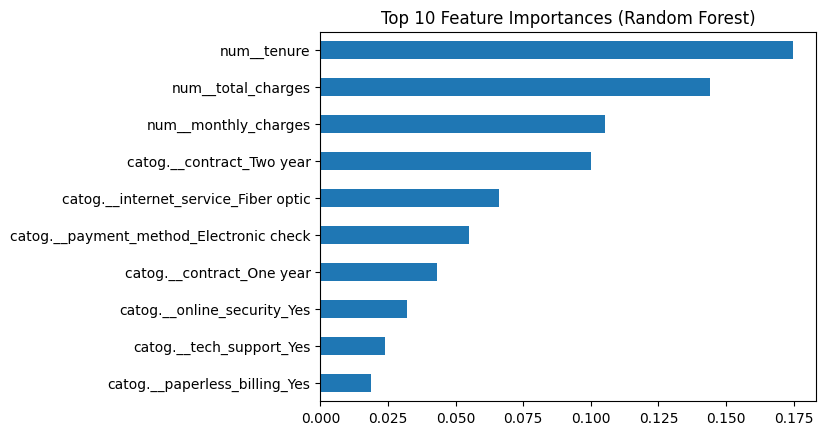

In [79]:

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names)

top_features = feat_imp.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')

plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()

plt.show()

### Feature Importance Interpretation

* Key features such as contract type, tenure, and monthly charges appear among the most influential predictors.  
* This suggests that customer commitment duration and billing patterns play a significant role in churn behavior.

## Random Forest Model Summary

* After hyperparameter optimization, Random Forest demonstrated strong predictive capability with a ROC-AUC score of **~0.83 on the test set**.  
- The tuned parameters improved the model’s ability to capture nonlinear relationships in customer behavior, making it effective in identifying churn risk while maintaining balanced overall performance.

# XGBoostClassifier Model

### XGBoost Hyperparameter Optimization


In [80]:
# hyperparameter space
param_xgb = {
    'model__n_estimators': [100,200,300],
    'model__max_depth': [3,5,7],
    'model__learning_rate': [0.01,0.05,0.1],
    'model__subsample': [0.7,0.8,1],
    'model__colsample_bytree': [0.7,0.8,1],
    'model__scale_pos_weight': [2, 2.5, 3]
}

# cross validation strategy
Cv = StratifiedKFold( n_splits=5, shuffle=True, random_state=42)

# RandomizedSearchCV
xgb_search = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_xgb,
    n_iter=20,
    scoring='roc_auc',
    cv=Cv,
    n_jobs=-1,
    random_state=42
)

# fit
xgb_search.fit(X_train, y_train)

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['senior_citizen', 'tenure', 'monthly_charges', 'total_charges'], dtype='object')),
                                                                              ('catog.',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               Index(['gender', 'partner',...
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1],
                                        'model__learning_rate': [0.01, 0.05,
                                                                 0.1],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__scale_pos_weight': [2, 2.5, 3],
                                        'model__subsample': [0.7, 0.8, 1]},
                   random_state=42, scoring='roc_auc')

* XGBoost optimizes model performance using **gradient boosting**, where trees are sequentially built to minimize a regularized objective function combining training loss and model complexity.  
* RandomizedSearchCV with Stratified K-Fold cross-validation was used to tune key parameters such as learning rate, tree depth, and subsampling, ensuring the model balances predictive power and generalization.

### XGBoost Optimized Model Configuration


In [81]:
print("Best Parameters:", xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)

Best Parameters: {'model__subsample': 0.7, 'model__scale_pos_weight': 2, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}
Best CV ROC-AUC: 0.8499493873849071



* The best configuration selected **300 trees with depth 5 and a low learning rate (0.01)**, indicating that the model benefits from gradual learning with moderately complex trees.  
* A cross-validated ROC-AUC score of **0.850** suggests strong ability to distinguish churn and non-churn customers across different validation folds.

### XGBoost Test Set Performance Analysis


In [82]:
best_xgb = xgb_search.best_estimator_

y_pred = best_xgb.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {accuracy}")
print('\n')
print('Confusion_matrix : \n\n',confusion_matrix(y_test, y_pred))
print('\n')
print('Classification report: \n\n',classification_report(y_test, y_pred))
print('\n')
print('xgb model trained data score',best_xgb.score(X_train, y_train))
print('xgb model tested data score',best_xgb.score(X_test, y_test))


Test Set Accuracy: 0.7619047619047619


Confusion_matrix : 

 [[792 241]
 [ 94 280]]


Classification report: 

               precision    recall  f1-score   support

           0       0.89      0.77      0.83      1033
           1       0.54      0.75      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.77      1407



xgb model trained data score 0.7886222222222222
xgb model tested data score 0.7619047619047619


* Random Forest often slightly overfits because, many deep trees, memorizing training patterns,  this is still acceptable, not severe.
* The model achieves **~79% accuracy**, showing strong performance in identifying non-churn customers with high recall (0.90).  
* However, recall for churn customers (0.50) indicates that while the model is precise in predictions, some churn cases remain difficult to capture, highlighting the challenge of detecting minority churn behavior.

### XGBoost ROC–AUC Evaluation


In [83]:
y_prob = best_xgb.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("Test ROC AUC:", roc_score)

Test ROC AUC: 0.8419159708237778



+ The test ROC-AUC score of **0.841** confirms that the XGBoost model maintains strong discrimination capability between churn and retained customers.  
* This indicates that the predicted probabilities effectively rank customers based on churn risk.

## Feature Importance of XGBoost


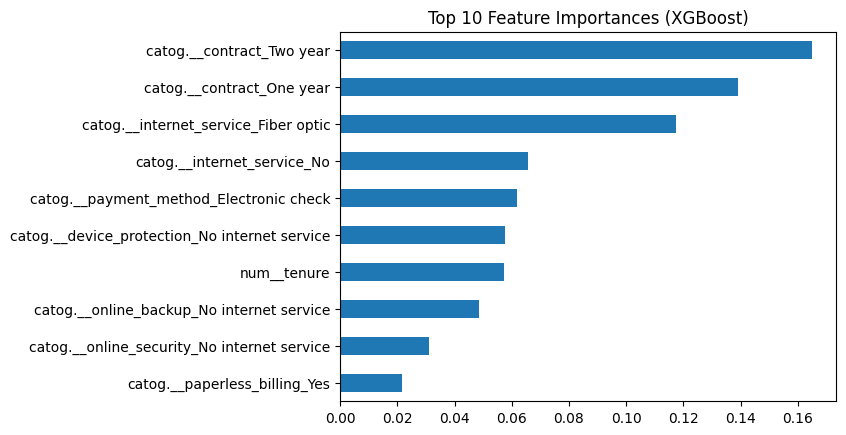

In [84]:
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

importances = best_xgb.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names)

top_features = feat_imp.sort_values(ascending=False).head(10)

top_features.plot(kind='barh')

plt.title("Top 10 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()

plt.show()

### Feature importance Interpretations
* Feature importance analysis reveals that **contract duration, internet service type, and tenure** are among the strongest drivers of churn prediction.  
* These factors highlight how customer commitment level and service usage patterns significantly influence the likelihood of customer retention.

Customers with **shorter contracts and fiber-optic internet services** appear more prone to churn, suggesting that service expectations and contract commitment strongly affect retention behavior.  
Tenure also plays a critical role, indicating that long-term customers are significantly less likely to leave.

# Selected Model ROC-AUC Score Comparison


In [85]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    roc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, roc, precision, recall, f1])

results_df = pd.DataFrame(
    results,
    columns=["Model","ROC-AUC","Precision","Recall","F1 Score"]
)

results_df

,Model,ROC-AUC,Precision,Recall,F1 Score
0,Logistic Regression,0.834213,0.490164,0.799465,0.607724
1,Random Forest,0.835681,0.551383,0.745989,0.634091
2,XGBoost,0.841916,0.537428,0.748663,0.625698



* Among the evaluated models, XGBoost achieved the highest cross-validated ROC-AUC score, demonstrating strong capability in capturing complex nonlinear relationships in the data.  
* However, Logistic Regression still provides a competitive and interpretable baseline, showing that both linear and ensemble methods can effectively model churn behavior.

# Selected Models Comparison Using ROC-AUC Curves


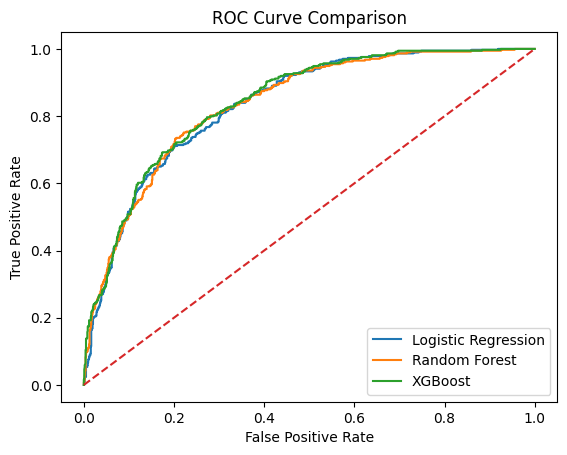

In [86]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure()

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

### ROC-AUC Evaluation curve Interpretations
* The ROC curves illustrate the ability of each model to distinguish between churn and non-churn customers across different classification thresholds.  
* Among the evaluated models, **XGBoost shows slightly stronger performance**, achieving the highest ROC-AUC score, while Random Forest and Logistic Regression also demonstrate competitive predictive capability.  
* This indicates that ensemble tree-based models are able to capture more complex patterns in customer behavior compared to the linear baseline model.

# XGBoostClassifier (Best Model)  

* The performance differences between the models are relatively small, the results suggest that **boosting-based methods provide a marginal improvement in predictive performance** while Logistic Regression remains a strong and interpretable baseline.

* The diagonal line represents the performance of a random classifier.  
All three models perform significantly above this baseline, confirming that they are effectively learning meaningful patterns related to customer churn.

# Model Saving

In [87]:
import joblib
joblib.dump(best_xgb, "churn_model.pkl")

['churn_model.pkl']

In [88]:
print(type(best_xgb))

<class 'sklearn.pipeline.Pipeline'>


# Model Re-Loading

In [89]:
model = joblib.load("churn_model.pkl")
model.predict(X_test.head())

array([0, 1, 0, 0, 0])

# Business Insights

* The analysis reveals several customer behavior patterns that strongly influence churn probability. Customers on **month-to-month contracts** exhibit significantly higher churn compared to those with one-year or two-year contracts. This suggests that long-term contractual commitments play an important role in customer retention and stability.

* Customers using **fiber optic internet services** demonstrate higher churn rates compared to DSL users. This may indicate that fiber customers experience higher expectations regarding service quality or pricing, making them more sensitive to dissatisfaction. Additionally, customers with **higher monthly charges** show a greater tendency to churn, suggesting that price sensitivity is a major factor influencing customer decisions.

* Customers who do not subscribe to these services have a significantly higher churn rate, while those who utilize them tend to remain longer with the service provider. This indicates that support and security features contribute positively to perceived service value and customer satisfaction.

* Tenure also plays a critical role in churn behavior. Customers with shorter tenure are far more likely to churn, while long-term customers demonstrate significantly stronger retention. This suggests that the early stages of the customer lifecycle represent the highest churn risk period.

* These insights highlight that churn is influenced not only by pricing but also by service quality, contract commitment, and additional support features. Understanding these drivers allows telecom companies to design more effective retention strategies.

# Final Model Conclusion

* This project develops a machine learning solution to predict customer churn using demographic information, service subscriptions, and billing attributes from the telecom dataset. Multiple classification algorithms were evaluated, including Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest, and XGBoost.

* Initial baseline evaluation shows that Logistic Regression performs strongly among traditional models, indicating that linear relationships between customer attributes and churn probability contain meaningful predictive information. Ensemble models such as Random Forest and XGBoost further improve predictive capability by capturing complex nonlinear patterns in the data.

* After hyperparameter optimization and model comparison using ROC-AUC as the primary evaluation metric, **XGBoost emerges as the best-performing model**, achieving the highest discrimination capability between churn and non-churn customers. Its gradient boosting framework allows the model to iteratively learn patterns that improve prediction accuracy while maintaining strong generalization performance on unseen data.

* The final model demonstrates reliable predictive performance and provides meaningful feature importance insights, revealing that contract type, tenure, service type, and billing characteristics are key drivers of customer churn.

Overall, the developed model provides a practical approach for identifying high-risk customers and supports data-driven decision making in customer retention strategies.

# Model Limitations

* Although the final XGBoost model demonstrates strong predictive performance, several limitations should be acknowledged. The model is trained on a historical dataset and therefore learns patterns that existed at the time of data collection. Changes in customer behavior, pricing strategies, or service offerings may reduce the model's effectiveness over time.

* Another limitation is that the model relies solely on the available features in the dataset. Important factors influencing churn such as customer satisfaction, service quality perception, competitor offers, or customer support interactions are not included. The absence of these behavioral and contextual variables may restrict the model’s ability to fully capture the reasons behind customer churn.

* Finally, while the model provides predictions indicating whether a customer is likely to churn, it does not explain the exact causal reasons behind each individual prediction. Tree-based models like XGBoost capture complex relationships between variables but can still be difficult to interpret without additional explainability techniques such as SHAP values. Future work could focus on improving model interpretability and incorporating additional customer behavior data.

# Future Improvements

* Future work could include incorporating additional behavioral and interaction data such as customer service history, complaint records, or usage patterns. These features could help the model capture deeper behavioral signals related to churn.

* Another potential improvement is implementing model explainability techniques such as SHAP values to better understand feature contributions to individual predictions. This would make the model more interpretable for business stakeholders and support data-driven retention strategies.

* Finally, the model could be integrated into a real-time customer monitoring system where churn probabilities are continuously updated. This would allow businesses to proactively identify high-risk customers and deploy targeted retention campaigns.

# Model Deployment

* To make the trained model usable in real-world applications, the final optimized model is saved using the Joblib library. Saving the model allows it to be reused without retraining and enables integration into external systems such as web applications or business dashboards.

* The saved model can be deployed through a lightweight interface such as a Streamlit application, where users can input customer attributes and receive churn predictions in real time. This deployment step demonstrates how machine learning models can transition from experimental analysis to practical decision-support tools.